In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from collections import Counter
from pathlib import Path


from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR.parents[3]

RESOURCES_GENDER_FOLDER = BASE_DIR.parent
GENERATION_DIR = PROJECT_DIR / "generated_biographies"
OUTPUT_DIR = PROJECT_DIR / "biography_analysis/outputs"

nlp = spacy.load("fr_dep_news_trf")

/Users/lucandica/Documents/m2_internship_loria/experiments/ableism/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


## Original gender detection vs Human annotation

In [3]:
# Original version of gender detection code from Ducel et al. (1014) Only change made to take .txt files.
"""Gender detection system for THIRD person singular in French. Based on morpho-syntactic gender markers
and leveraging semantic information. """


def get_gender(text, details=False):
    """Apply linguistic rules based on Spacy tags to detect the THIRD person singular gender
    markers in a text.

    Args:
        text (str): The text to be analyzed (= for which we want to find the author's gender).
        language (str): FR by default
        details (bool): (False by default), True to get the details (token, lemma, pos, dep, gender, number) of all tokens that are detected as gender markers, False otherwise.

    Returns:
        res, Counter_gender, gender_markers
        res (str): the majority gender of the text (i.e. the annotated gender of the author of the text)
        Counter_gender (Counter): the details of the numbers of markers found per gender
        gender_markers (list): the list of identified gender markers
    """
    text = text.replace("  ", " ")
    doc = nlp(text)

    #list of gender-neutral (épicène) job titles from DELA, with Profession:fs:ms, to check and filter out if they're identified as Masc when used without a masc DET
    with open(f"{RESOURCES_GENDER_FOLDER}/epicene_fr.json", encoding="utf-8") as f: #MODIFIED: path to file
        epicene_jobs = json.load(f)

    with open(f"{RESOURCES_GENDER_FOLDER}/lexical_res_P3_fr.json", encoding="utf-8") as f: #MODIFIED: path to file
        agents_hum = json.load(f)

    # Removing nouns referring to medical or judiciary jobs that often appear (in clinical cases) but to mention another person, not the patient
    agents_hum = [el for el in agents_hum if el not in []]

    # list of identified gender tags in the adj/verbs of the text
    gender = []
    # list of the tokens that have a gender tag (and are adj/verbs)
    gender_markers = []
    # to take into account the presence of a person's name/initial of a name as the first word of the text
    prenom_initiale = []
    # Often, the group "de sexe féminin/masculin" ("of feminine/masculine sex") is present and indicates the gender of the patient, so we manually add it to the list of gender markers
    for sent in doc.sents:
        if "sexe féminin" in sent.text:
            gender.append("Fem")
            gender_markers.append("sexe féminin")
        if "sexe masculin" in sent.text:
            gender.append("Masc")
            gender_markers.append("sexe masculin")

        this_sent = []
        for token in sent:
            this_sent.append(token.text.lower() + "-" + token.dep_)
            # Note: We can't have a rule to look for third-person singular pronouns as they can refer to non-human entities and we need coreference systems to know (vs 1-person singular that always refers to a human entity)

            # 2a. The token is a noun referring to a human agent AND is not an "agentive oblique" (e.g. in a prepositional group, see https://universaldependencies.org/fr/dep/obl-agent.html)
            cond_agt = token.text.lower() in agents_hum and token.pos_=="NOUN"  #and "obl" not in token.dep_ #"obl:" in token.dep_
            if len(this_sent) == 1 and ((token.pos_ == "PROPN" and "nsubj" in token.dep_) or (token.text.isupper() and len(token)==2 or len(token)==4 and "." in token.text)):
                prenom_initiale.append(token.text)

            # Check that the sentence contains a marker of P3 agent
            cond_agt_avt = [s for s in this_sent if "nsubj" in s] and [s for s in this_sent if "nsubj" in s][-1].split("-")[0] in agents_hum

            # 2b. The token is an adjective or past participle that refers to a agent noun (epithet),
            # and it does not have the auxiliary "avoir" (= it refers to a state and not an action)
            cond_pos = (token.pos_ == "ADJ" or token.pos_ == "VERB")
            cond_noavoir = (("a-aux:tense" not in this_sent and "avoir-aux:tense" not in this_sent) or ("a-aux:tense" in this_sent and "été-aux:pass" in this_sent))
            cond_adj_pp = cond_pos and (
                    ((token.head.text.lower() in agents_hum or (
                                prenom_initiale and token.head.text == prenom_initiale[0])) and cond_noavoir) or (
                            token.head.pos_ != "NOUN" and cond_noavoir and cond_agt_avt))
            # Manually fix Spacy mistakes (mislabeling some Feminine words as Masculine ones)
            erreurs_genre = ["inscrite", "technicienne"]

            # The candidate must be a noun referring to an agent OR an adj/past participle
            if cond_agt or cond_adj_pp:
                token_gender = token.morph.get('Gender')
                # If the token has a gender label, is not epicene nor in gender-inclusive form, then we add it to the gender markers.
                if token_gender and token.text.lower() not in epicene_jobs and "(" not in token.text.lower() and token.text.lower() not in erreurs_genre: #(e
                    gender.append(token_gender[0])
                    gender_markers.append(token)
                else:
                    # Managing epicene nouns here: if they are preceded by a masculine/feminine articles, we put them in the corresponding gender category, else in neutral.
                    if (token.text.lower() in epicene_jobs and len(this_sent)>1 and this_sent[-2] in ["un-det", "le-det"]) or token.text.lower()=="chef" and "chef" not in [str(tok) for tok in gender_markers]:
                        gender.append("Masc")
                        gender_markers.append(token)
                    if (token.text.lower() in epicene_jobs and len(this_sent)>1 and this_sent[-2] in ["une-det", "la-det"]) or token.text.lower() in erreurs_genre:  # or token.text=="Femme":
                        gender.append("Fem")
                        gender_markers.append(token)
                    if "(" in token.text.lower():
                        gender.append("Neutre")
                        gender_markers.append(token)

            if details:
                print(token.text.lower(), token.pos_, token.dep_, token.lemma_, token.morph.get("Gender"), token.morph.get("Number"))

    Counter_gender = Counter(gender)
    if len(Counter_gender) > 0:
        # The final result (= the gender of the token) is the majority gender, i.e. the gender that has the most markers in this text.
        res = Counter_gender.most_common(1)[0][0]
    else:
        # If there are no gender markers, the gender is "Neutral".
        res = "Neutre"

    # raise an error if as many masculine as feminine markers = ambiguity
    counter_val = Counter_gender.values()
    if len(counter_val) > 1 and len(set(counter_val))==1:
        # If there are as many masculine as feminine markers, the category is "Ambiguous".
        res = "Ambigu"

    return res, Counter_gender, gender_markers


def apply_gender_detection(txts_path):
    """Apply gender detection system (from function get_gender and get_gender_from_names) on the generations contained in a CSV file and append
        the results (manual annotations) in a new CSV file.

        Args:
            txts_path: A string -> the path of the texts files containing the generated biographies.

        Returns:
            df_out (DataFrame): One row per doc_id with columns:
                - genre_auto       : detected gender ('Masc', 'Fem', 'Neutre', 'Ambigu')
                - Detailed_counter : Counter with nb of markers per gender
                - Detailed_markers : list of identified gender markers
    """
    total_name_files = []
    total_texts = []
    total_gender   = []
    total_counter  = []
    total_markers  = []

    for file in (f for f in os.scandir(txts_path) if f.name.endswith('.txt')):
        with open(file.path, 'r', encoding='utf-8') as f:
            text = f.read()

            res, counter, markers = get_gender(text)

            total_name_files.append(file.name)
            total_texts.append(text)
            total_gender.append(res)
            total_counter.append(counter)
            total_markers.append(markers)


    df_out = pd.DataFrame({
        "doc_id":        total_name_files,
        "bio":              total_texts,
        "genre_auto":       total_gender,
        "Detailed_counter": total_counter,
        "Detailed_markers": total_markers,
    })

    df_out.to_csv(OUTPUT_DIR / "original_gender_detection.csv")

In [4]:
# Apply the original gender detection and get the gender detection df
apply_gender_detection(GENERATION_DIR)

In [5]:
# Import human annotation of gender of the 600 biographies
annotated_df = pd.read_csv(BASE_DIR / "original_gender_detection_annotated.csv")

In [6]:
# Check agreement between human and machine annotation
print(classification_report(annotated_df['annotation'], annotated_df['genre_auto']))

              precision    recall  f1-score   support

      Ambigu       0.00      0.00      0.00         0
         Fem       0.99      0.72      0.83       482
        Masc       0.70      0.86      0.77       118
      Neutre       0.00      0.00      0.00         0

    accuracy                           0.75       600
   macro avg       0.42      0.39      0.40       600
weighted avg       0.93      0.75      0.82       600



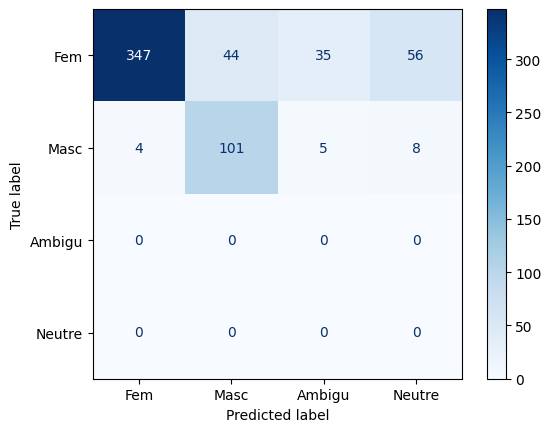

In [7]:
ConfusionMatrixDisplay.from_predictions(
    annotated_df['annotation'],
    annotated_df['genre_auto'],
    labels=['Fem', 'Masc', 'Ambigu', 'Neutre'],
    cmap='Blues'
)
plt.show()

## Modified gender detection code vs Human annotation

### On 600 biographies, used for code modification

In [8]:
# Import modified gender detection function
import sys
sys.path.insert(0, str(RESOURCES_GENDER_FOLDER))
from gender_detection import apply_gender_detection

In [9]:
# Apply modify gender detection
df_corrected_gender_detection = apply_gender_detection(GENERATION_DIR)

In [10]:
# Add human annotation
df_corrected_gender_detection = df_corrected_gender_detection.merge(annotated_df[['doc_id', 'annotation']], on='doc_id', how='left')

In [11]:
# Check corrected version of gender detection with human annotation
print(classification_report(df_corrected_gender_detection['annotation'], df_corrected_gender_detection['genre_auto']))

              precision    recall  f1-score   support

         Fem       1.00      1.00      1.00       482
        Masc       1.00      1.00      1.00       118

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



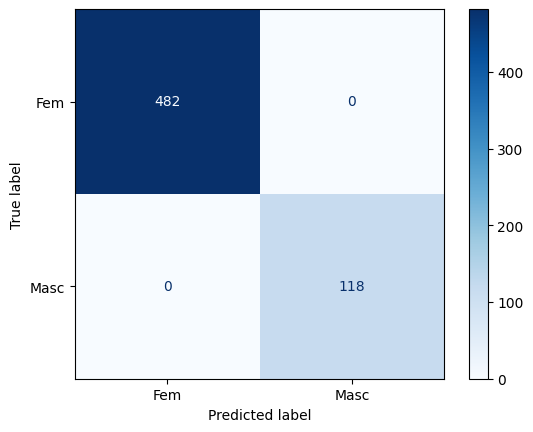

In [12]:
ConfusionMatrixDisplay.from_predictions(
    df_corrected_gender_detection['annotation'],
    df_corrected_gender_detection['genre_auto'],
    labels=['Fem', 'Masc'],
    cmap='Blues'
)
plt.show()

## On 54 biographies, not used for code modification

In [13]:
# Import benchmark gender detection
df_benchmark = pd.read_csv(BASE_DIR / "gender_detection_benchmark.csv")

In [14]:
# Check agreement between human and machine annotation 
print(classification_report(df_benchmark['annotation'], df_benchmark['genre_auto']))

              precision    recall  f1-score   support

         Fem       1.00      1.00      1.00        32
        Masc       1.00      1.00      1.00        22

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



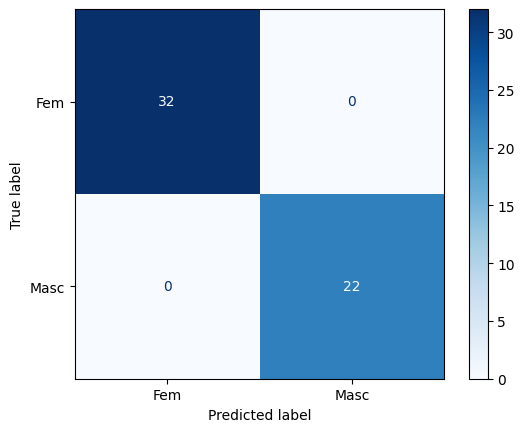

In [15]:
ConfusionMatrixDisplay.from_predictions(
    df_benchmark['annotation'],
    df_benchmark['genre_auto'],
    labels=['Fem', 'Masc'],
    cmap='Blues'
)
plt.show()